# 04. Modelado

## Objetivo
Entrenar y comparar cuatro modelos de clasificación para predecir la variable depression, utilizando los datos preparados en la fase anterior, con el fin de identificar el modelo con mejor desempeño e interpretar sus resultados mediante métricas y matrices de confusión.

## 1. Carga de librerías

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

## 2. Carga de datos procesados

In [12]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

display(Markdown("## Dimensiones de los conjuntos"))
display(pd.DataFrame({
    "Dataset": ["X_train", "X_test", "y_train", "y_test"],
    "Filas": [X_train.shape[0], X_test.shape[0], y_train.shape[0], y_test.shape[0]],
    "Columnas": [X_train.shape[1], X_test.shape[1], 1, 1]
}))

## Dimensiones de los conjuntos

,Dataset,Filas,Columnas
0,X_train,22320,13
1,X_test,5581,13
2,y_train,22320,1
3,y_test,5581,1


## 3. Identificación de variables numéricas y categóricas

In [13]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

display(Markdown("## Resumen de variables"))
display(pd.DataFrame({
    "Tipo": ["Numéricas", "Categóricas"],
    "Cantidad": [len(num_cols), len(cat_cols)],
    "Columnas": [", ".join(num_cols), ", ".join(cat_cols)]
}))

## Resumen de variables

,Tipo,Cantidad,Columnas
0,Numéricas,6,"age, academic_pressure, cgpa, study_satisfacti..."
1,Categóricas,7,"gender, sleep_duration, dietary_habits, have_y..."


## 4. Definición de transformadores

In [14]:
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

## 5. Construcción de pipelines

In [15]:
models = {
    "Regresión Logística": Pipeline([
        ("preprocessor", preprocessor_scaled),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    
    "Árbol de Decisión": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("model", DecisionTreeClassifier(max_depth=5, random_state=42))
    ]),
    
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=8,
            random_state=42
        ))
    ]),
    
    "KNN": Pipeline([
        ("preprocessor", preprocessor_scaled),
        ("model", KNeighborsClassifier(n_neighbors=7))
    ])
}

In [25]:
display(Markdown("## Visualización de pipelines"))

for name, pipe in models.items():
    display(Markdown(f"### {name}"))
    display(pipe)

## Visualización de pipelines

### Regresión Logística

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'academic_pressure',
                                                   'cgpa', 'study_satisfaction',
                                                   'work_study_hours',
                                                   'financial_stress']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'sleep_duration',
                                                   'dietary_habits',
                                                   'have_you_ever_had_suicidal_thoughts_',
                                                   'family_history_of_mental_illness',
                                                   'degree_grouped',
                                                   'city_grouped'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

### Árbol de Decisión

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age', 'academic_pressure',
                                                   'cgpa', 'study_satisfaction',
                                                   'work_study_hours',
                                                   'financial_stress']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'sleep_duration',
                                                   'dietary_habits',
                                                   'have_you_ever_had_suicidal_thoughts_',
                                                   'family_history_of_mental_illness',
                                                   'degree_grouped',
                                                   'city_grouped'])])),
                ('model',
                 DecisionTreeClassifier(max_depth=5, random_state=42))])

### Random Forest

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age', 'academic_pressure',
                                                   'cgpa', 'study_satisfaction',
                                                   'work_study_hours',
                                                   'financial_stress']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'sleep_duration',
                                                   'dietary_habits',
                                                   'have_you_ever_had_suicidal_thoughts_',
                                                   'family_history_of_mental_illness',
                                                   'degree_grouped',
                                                   'city_grouped'])])),
                ('model',
                 RandomForestClassifier(max_depth=8, n_estimators=200,
                                        random_state=42))])

### KNN

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'academic_pressure',
                                                   'cgpa', 'study_satisfaction',
                                                   'work_study_hours',
                                                   'financial_stress']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'sleep_duration',
                                                   'dietary_habits',
                                                   'have_you_ever_had_suicidal_thoughts_',
                                                   'family_history_of_mental_illness',
                                                   'degree_grouped',
                                                   'city_grouped'])])),
                ('model', KNeighborsClassifier(n_neighbors=7))])

## 6. Entrenamiento de modelos

In [18]:
results = []
predictions = {}
probabilities = {}
fpr_dict = {}
tpr_dict = {}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    predictions[name] = y_pred
    probabilities[name] = y_prob
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    fpr_dict[name] = fpr
    tpr_dict[name] = tpr
    
    results.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).sort_values(by="F1-score", ascending=False).reset_index(drop=True)

display(Markdown("## Comparación de métricas"))
display(
    results_df.style
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
    .background_gradient(subset=["Recall", "F1-score", "ROC-AUC"], cmap="Blues")
)

## Comparación de métricas

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Regresión Logística,0.8445,0.8578,0.8804,0.8689,0.9188
1,KNN,0.8267,0.8303,0.8849,0.8568,0.8888
2,Random Forest,0.8237,0.8211,0.8935,0.8558,0.9076
3,Árbol de Decisión,0.8206,0.8357,0.8635,0.8494,0.8908


## Nota metodológica sobre las métricas

Dado que la variable objetivo depression es binaria, el problema corresponde a una tarea de clasificación. Por esta razón, no se emplean métricas propias de regresión como R² o coeficiente de correlación lineal. En su lugar, se utilizan métricas adecuadas para clasificación: accuracy, precision, recall, F1-score y ROC-AUC.

Adicionalmente, se incorporan matrices de confusión y curvas ROC para complementar la interpretación del desempeño de cada modelo.

Regresión Logística: Se utilizó como modelo base por ser interpretable, estable y apropiado para clasificación binaria

Árbol de Decisión: Permite explicar decisiones mediante reglas y facilita la interpretación visual del comportamiento del modelo

Random Forest: Se incluyó como mejora del árbol de decisión, ya que combina múltiples árboles y reduce el sobreajuste

KNN: Se utilizó como método basado en similitud entre observaciones, útil para comparar un enfoque distinto a los modelos anteriores

## 7. Evaluación comparativa

In [8]:
best_model_name = results_df.loc[0, "Modelo"]
display(Markdown(f"## Mejor modelo seleccionado: **{best_model_name}**"))

## Mejor modelo seleccionado: **Regresión Logística**

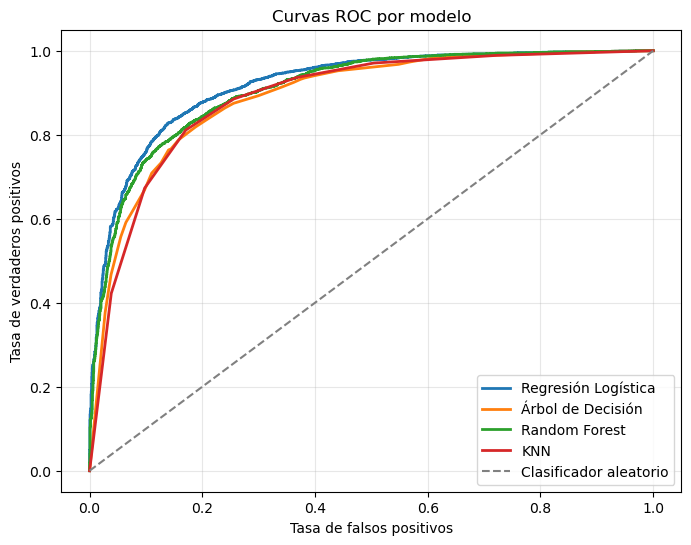

In [19]:
plt.figure(figsize=(8,6))

for name in models.keys():
    plt.plot(fpr_dict[name], tpr_dict[name], linewidth=2, label=name)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Clasificador aleatorio")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curvas ROC por modelo")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

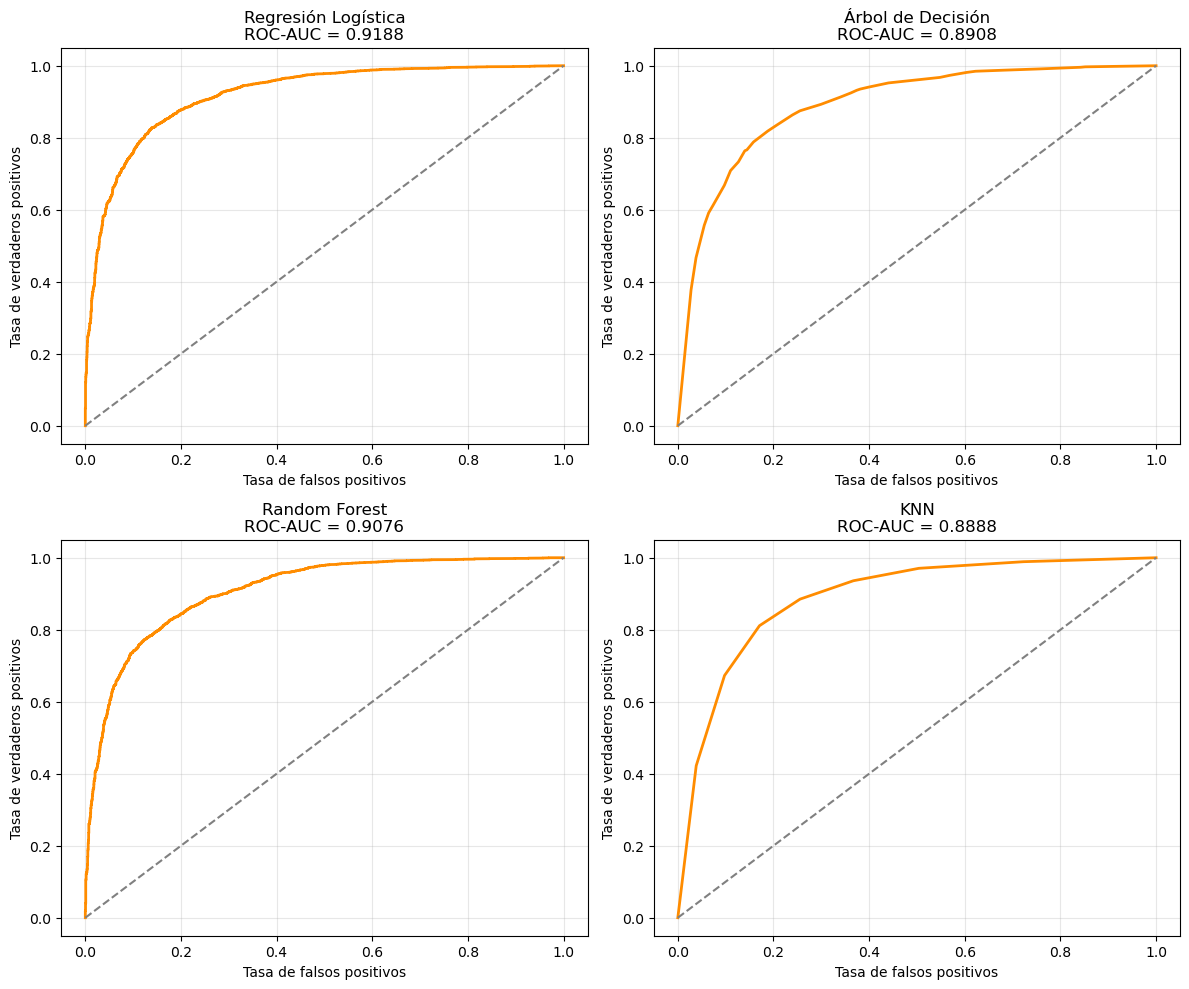

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, name in zip(axes, models.keys()):
    auc_value = results_df.loc[results_df["Modelo"] == name, "ROC-AUC"].values[0]
    
    ax.plot(fpr_dict[name], tpr_dict[name], color="darkorange", linewidth=2)
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
    ax.set_title(f"{name}\nROC-AUC = {auc_value:.4f}")
    ax.set_xlabel("Tasa de falsos positivos")
    ax.set_ylabel("Tasa de verdaderos positivos")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Matrices de confusión

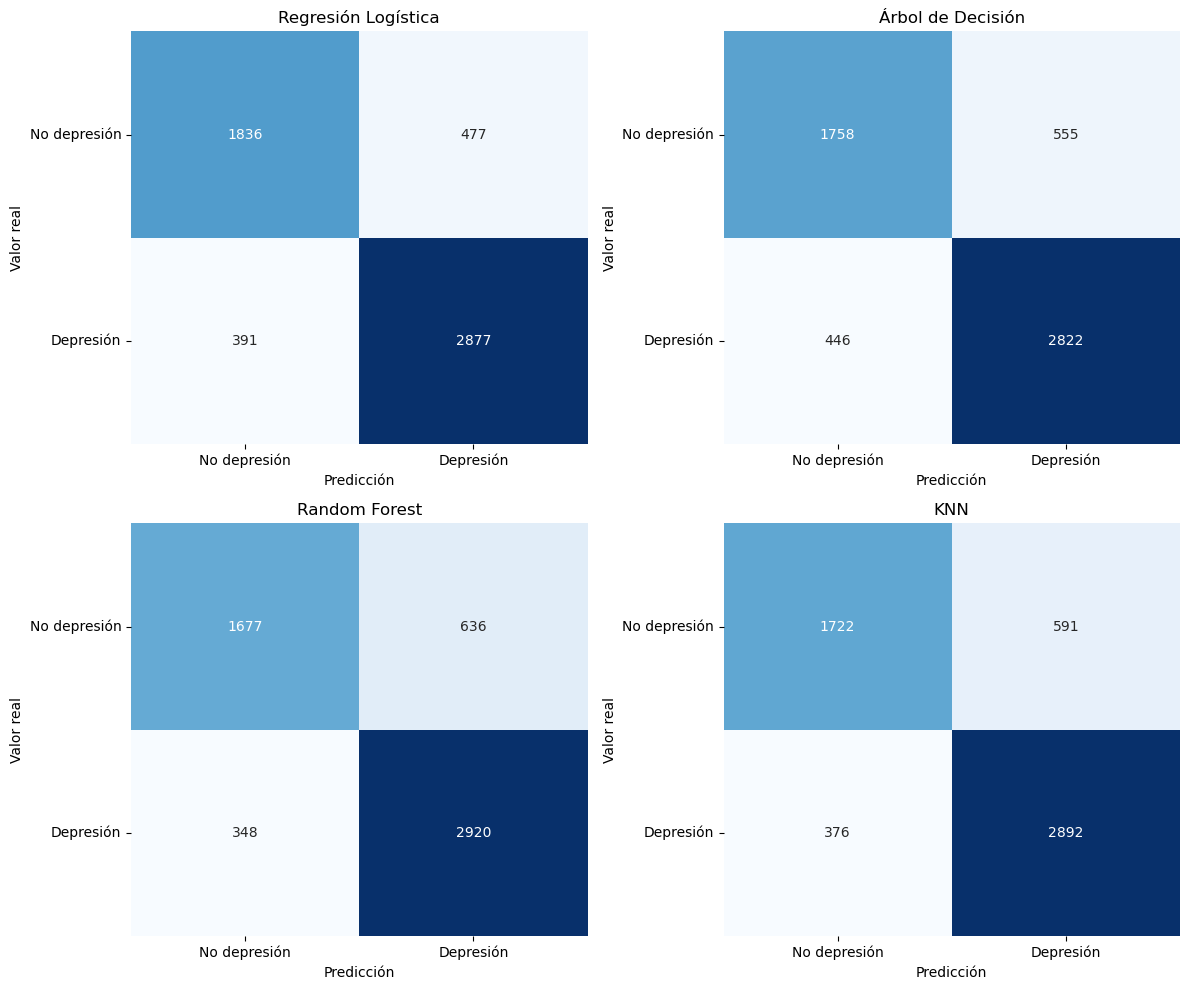

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )
    
    ax.set_title(name)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")
    ax.set_xticklabels(["No depresión", "Depresión"])
    ax.set_yticklabels(["No depresión", "Depresión"], rotation=0)

plt.tight_layout()
plt.show()

## Interpretación de la matriz de confusión

La matriz de confusión permite analizar los aciertos y errores del modelo:

- Verdaderos positivos: casos de depresión correctamente identificados.
- Verdaderos negativos: casos sin depresión correctamente clasificados.
- Falsos positivos: estudiantes clasificados con depresión cuando no la presentan.
- Falsos negativos: estudiantes con depresión que el modelo no detectó.

En este problema, los falsos negativos son especialmente sensibles, porque implican no identificar estudiantes que sí presentan depresión. Por ello, el recall es una métrica especialmente relevante.

## 9. Selección del mejor modelo

In [22]:
report_tables = []

for name, y_pred in predictions.items():
    report = classification_report(y_test, y_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose().reset_index()
    report_df.insert(0, "Modelo", name)
    report_tables.append(report_df)

classification_reports_df = pd.concat(report_tables, ignore_index=True)

display(Markdown("## Reportes de clasificación"))
display(
    classification_reports_df.style.format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1-score": "{:.4f}",
        "support": "{:.0f}"
    })
)

## Reportes de clasificación

,Modelo,index,precision,recall,f1-score,support
0,Regresión Logística,0,0.8244,0.7938,0.8088,2313
1,Regresión Logística,1,0.8578,0.8804,0.8689,3268
2,Regresión Logística,accuracy,0.8445,0.8445,0.8445,1
3,Regresión Logística,macro avg,0.8411,0.8371,0.8389,5581
4,Regresión Logística,weighted avg,0.8440,0.8445,0.8440,5581
5,Árbol de Decisión,0,0.7976,0.7601,0.7784,2313
6,Árbol de Decisión,1,0.8357,0.8635,0.8494,3268
7,Árbol de Decisión,accuracy,0.8206,0.8206,0.8206,1
8,Árbol de Decisión,macro avg,0.8166,0.8118,0.8139,5581
9,Árbol de Decisión,weighted avg,0.8199,0.8206,0.8199,5581


In [23]:
best_model_name = results_df.iloc[0]["Modelo"]
display(Markdown(f"## Mejor modelo según F1-score: **{best_model_name}**"))

## Mejor modelo según F1-score: **Regresión Logística**

## 10. Conclusiones

En esta fase se entrenaron cuatro modelos de clasificación: regresión logística, árbol de decisión, random forest y KNN. La comparación se realizó mediante métricas apropiadas para clasificación, complementadas con curvas ROC y matrices de confusión.

La inclusión de estas visualizaciones permitió evaluar no solo el desempeño global de los modelos, sino también su capacidad de discriminación y el tipo de errores cometidos. Esto facilita seleccionar un modelo final no únicamente por accuracy, sino también por su capacidad para identificar correctamente los casos positivos de depresión.